In [1]:
import numpy as np
import matplotlib.pyplot as plt

linspace() - generates an array of evenly spaced numbers over a specified mathematical interval<br>
cumsum() - cumulative sum<br>
hstack() - stacks array sequential in a horizontal direction(column wise)<br>
n_steps - no of trading days<br>
n_paths - no of simulation paths <br>

In [15]:
def simulate_GBM(S0, mu,sigma, T, n_steps, n_paths):
    dt = T/n_paths
    t = np.linspace(0,T,n_steps+1)
    Z = np.random.normal(0,1.0,size=(n_paths, n_steps))
    W = np.cumsum(np.sqrt(dt)*Z, axis=1)
    W = np.hstack((np.zeros((n_paths, 1)), W))
    drift = (mu - (0.5*sigma**2))*t
    shock = sigma*W
    S = S0*np.exp(drift + shock)
    return t, S

In [16]:
t, S = simulate_GBM(100, 0.05,0.2,1.0,252,5)

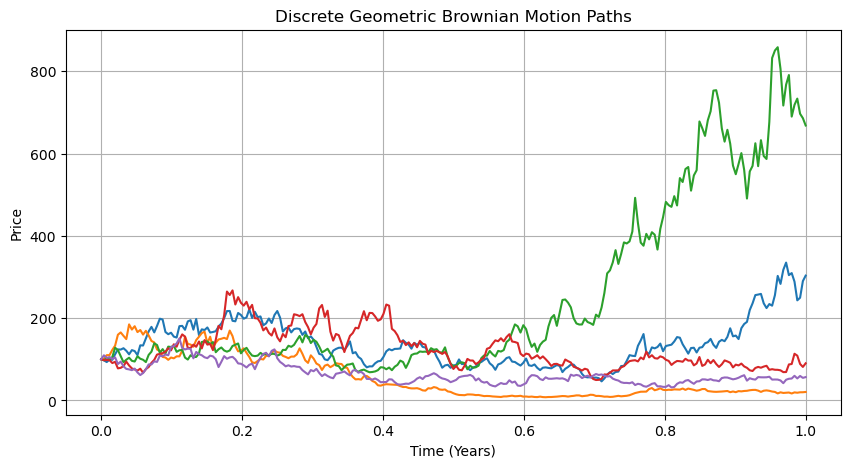

In [17]:
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.plot(t, S[i], lw=1.5)
plt.title("Discrete Geometric Brownian Motion Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Price")
plt.grid(True)
plt.show()